# Pseudobulk degs analysis in AIM2 ERA vs HC1
- AIFI L3 level - CertPro data

In [1]:
# load libraries
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('Matrix')
quiet_library("DESeq2")
quiet_library('dplyr')
quiet_library('SingleCellExperiment')
quiet_library('ggpubr')
quiet_library('knitr')
quiet_library('plotly')
quiet_library('hise')

In [2]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [2]:
# define working path
data_path = '/home/workspace/data/ra_longitudinal/scrna/certPro'
output_path = '/home/workspace/data/ra_longitudinal/output_results/certPro'
fig_path = '/home/workspace/data/ra_longitudinal/figures/certPro'
proj_name = 'ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_'

In [4]:
source('/home/workspace/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r')

# loading the pseudobulk data

In [3]:
cacheFiles(list('e998f299-a8d0-4137-9cfc-084d6b663ba0'))

[1] "downloading fileID e998f299-a8d0-4137-9cfc-084d6b663ba0"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/e998f299-a8d0-4137-9cfc-084d6b663ba0/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM2_psedobulk_object_list.rds"

In [5]:
# load pseudobulk data
aim2_pb <- readRDS(file.path(data_path,
                           "ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM2_psedobulk_object_list.rds"))

In [8]:
aim2_pb %>% names()

[1] "Activated memory B cell"             
 [2] "Adaptive NK cell"                    
 [3] "Adaptive NK cell_uk1_T"              
 [4] "ASDC"                                
 [5] "C1Q+ CD16 monocyte"                  
 [6] "CD14+ cDC2"                          
 [7] "CD27- effector B cell"               
 [8] "CD27+ effector B cell"               
 [9] "CD4 MAIT"                            
[10] "CD56bright NK cell"                  
[11] "CD8 MAIT"                            
[12] "CD8aa"                               
[13] "CD95 memory B cell"                  
[14] "cDC1"                                
[15] "CLP cell"                            
[16] "CM CD4 T cell"                       
[17] "CM CD4 T cell_uk1_CD8"               
[18] "CM CD4 T cell_uk2"                   
[19] "CM CD8 T cell"                       
[20] "CMP cell"                            
[21] "Core CD14 monocyte"                  
[22] "Core CD16 monocyte"                  
[23] "Core memory B cell"                  
[24] "Core naive B cell"                   
[25] "Core naive CD4 T cell"               
[26] "Core naive CD8 T cell"               
[27] "DN T cell"                           
[28] "Early memory B cell"                 
[29] "Erythrocyte"                         
[30] "GZMB- CD27- EM CD4 T cell"           
[31] "GZMB- CD27- EM CD4 T cell_uk1_CD8"   
[32] "GZMB- CD27+ EM CD4 T cell"           
[33] "GZMB- CD27+ EM CD4 T cell_uk1_CD8"   
[34] "GZMB+ Vd2 gdT"                       
[35] "GZMK- CD27+ EM CD8 T cell"           
[36] "GZMK- CD56dim NK cell"               
[37] "GZMK+ CD27+ EM CD8 T cell"           
[38] "GZMK+ CD27+ EM CD8 T cell_uk1_gdt"   
[39] "GZMK+ CD56dim NK cell"               
[40] "GZMK+ memory CD4 Treg"               
[41] "GZMK+ Vd2 gdT"                       
[42] "HLA-DRhi cDC2"                       
[43] "IL1B+ CD14 monocyte"                 
[44] "ILC"                                 
[45] "Intermediate monocyte"               
[46] "ISG+ CD14 monocyte"                  
[47] "ISG+ CD16 monocyte"                  
[48] "ISG+ CD56dim NK cell"                
[49] "ISG+ cDC2"                           
[50] "ISG+ MAIT"                           
[51] "ISG+ memory CD4 T cell"              
[52] "ISG+ memory CD4 T cell_uk1_CD8"      
[53] "ISG+ memory CD8 T cell"              
[54] "ISG+ naive B cell"                   
[55] "ISG+ naive CD4 T cell"               
[56] "ISG+ naive CD8 T cell"               
[57] "KLRB1+ memory CD4 Treg"              
[58] "KLRB1+ memory CD8 Treg"              
[59] "KLRF1- effector Vd1 gdT"             
[60] "KLRF1- GZMB+ CD27- EM CD8 T cell"    
[61] "KLRF1- GZMB+ CD27- memory CD4 T cell"
[62] "KLRF1+ effector Vd1 gdT"             
[63] "KLRF1+ GZMB+ CD27- EM CD8 T cell"    
[64] "KLRF1+_GZMB+_CD27-_EM_CD8_uk2"       
[65] "KLRF1+GZMB+_CD27-_EM_CD8_uk3"        
[66] "Memory CD4 Treg"                     
[67] "Memory CD8 Treg"                     
[68] "Naive CD4 Treg"                      
[69] "Naive Vd1 gdT"                       
[70] "pDC"                                 
[71] "Plasma cell"                         
[72] "Platelet"                            
[73] "Proliferating NK cell"               
[74] "Proliferating T cell"                
[75] "SOX4+ naive CD4 T cell"              
[76] "SOX4+ naive CD8 T cell"              
[77] "SOX4+ Vd1 gdT"                       
[78] "Transitional B cell"                 
[79] "Type 2 polarized memory B cell"

In [7]:
aim2_pb%>%length()

[1] 79

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


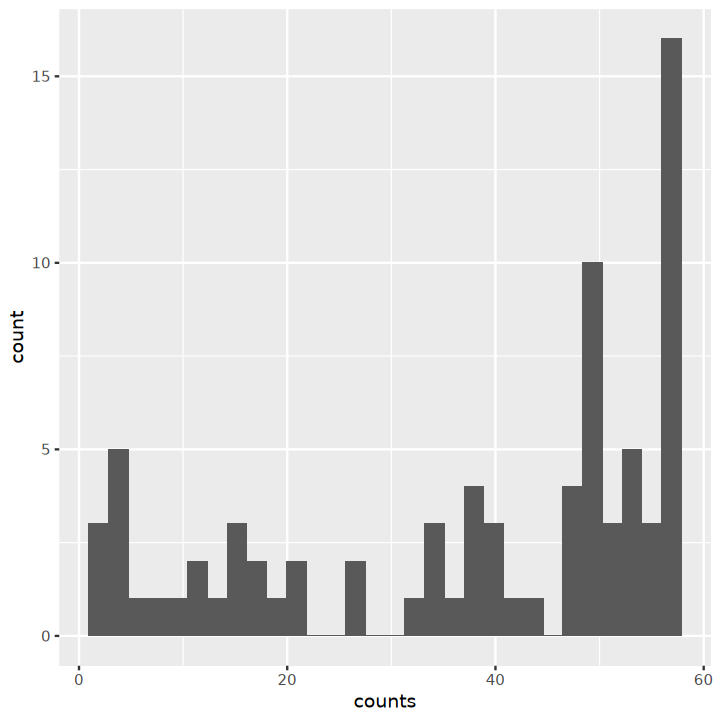

In [8]:
# check how many samples are present for each cell type
options(repr.plot.width = 6, repr.plot.height = 6)
sample_numbers = lapply(aim2_pb, ncol)%>%as.list()%>%
    as_tibble()%>%pivot_longer(cols=where(is.numeric),
                               names_to = 'cell_type', values_to = 'counts')
sample_numbers%>%ggplot(aes(x=counts)) + geom_histogram()

In [9]:
colnames(colData(aim2_pb[[1]]))

[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L3"                             "doublets_manual"                    
[23] "AIFI_L3_new"                         "Status_Xsec"                        
[25] "Status_Long"                         "anti_ccp3_finalCombined"            
[27] "days_to_conversion"                  "BMI"                                
[29] "CMV_Status_Subj"                     "age_conv"                           
[31] "bmi_conv"                            "file.batchID"                       
[33] "status"                              "psbulk_n_cells"                     
[35] "psbulk_counts"

In [12]:
# check the samples numbers in different group
count_status <- function(x, celltype_col = 'AIFI_L3_new', group_col = 'Status_Xsec') {
    sample_counts = colData(x)%>%as_tibble()%>%
        group_by(.data[[group_col]])%>%summarise(sample_number = n(),
                                         cell_type = unique(.data[[celltype_col]]))
    return(sample_counts)
}

# Applying the function to each SCE object in the list
status_counts <- lapply(aim2_pb, count_status)%>%data.table::rbindlist()%>%
    pivot_wider(id_cols = 'cell_type', names_from = 'Status_Xsec',
                values_from = 'sample_number', values_fill = 0)


`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


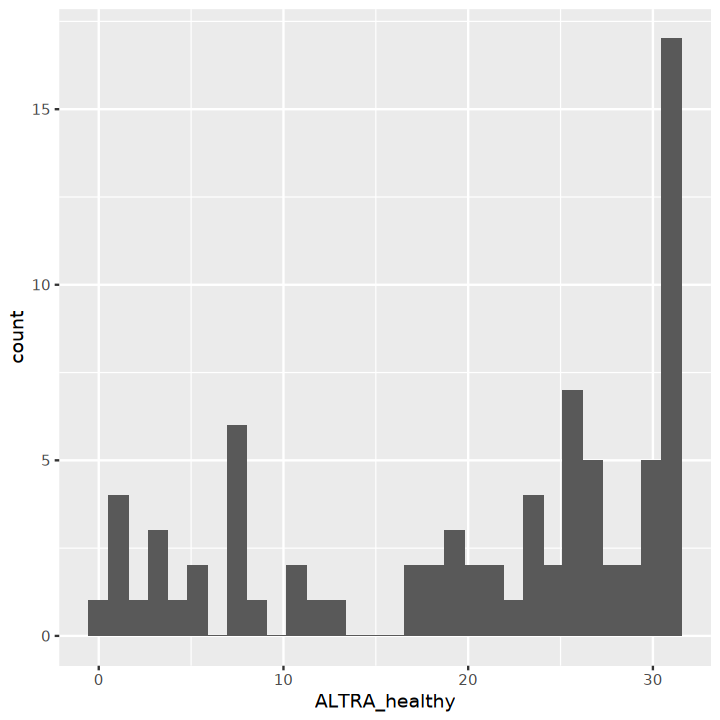

In [13]:
status_counts%>%ggplot(aes(x=ALTRA_healthy)) + geom_histogram()

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


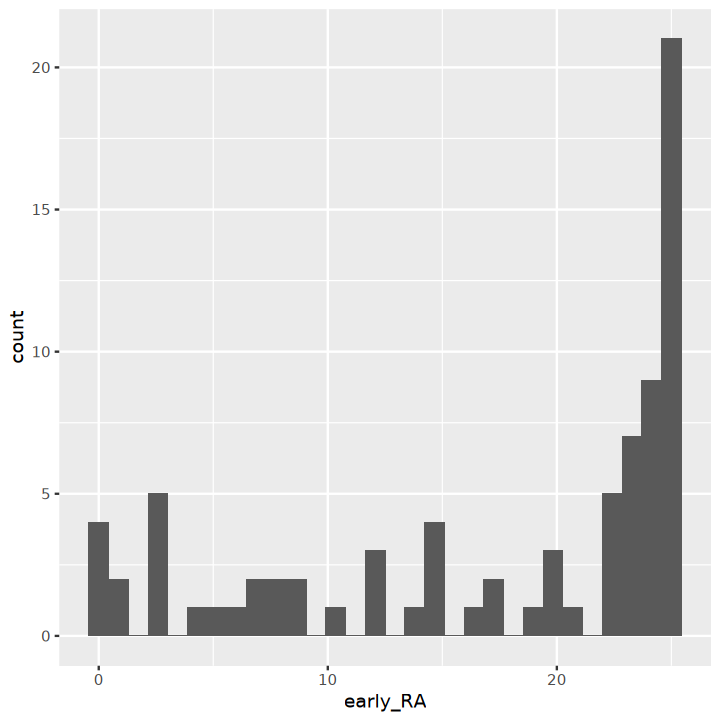

In [14]:
status_counts%>%ggplot(aes(x=early_RA)) + geom_histogram()

In [15]:
# selecting celltypes that has at least 5 early_RA samples and 5 HC samples
status_counts_fl = status_counts%>%filter(early_RA>=5&ALTRA_healthy>=5)

In [16]:
cell_types_to_keep = status_counts_fl%>%pull(cell_type)
cell_types_to_keep%>%length()

[1] 66

In [17]:
# check cell types being drop
names(aim2_pb)[!names(aim2_pb)%in%cell_types_to_keep]

[1] "Activated memory B cell"        "ASDC"                          
 [3] "CLP cell"                       "GZMK+ memory CD4 Treg"         
 [5] "ILC"                            "ISG+ MAIT"                     
 [7] "ISG+ memory CD4 T cell_uk1_CD8" "ISG+ memory CD8 T cell"        
 [9] "ISG+ naive CD8 T cell"          "KLRB1+ memory CD8 Treg"        
[11] "KLRF1+_GZMB+_CD27-_EM_CD8_uk2"  "Memory CD8 Treg"               
[13] "SOX4+ Vd1 gdT"

## subsetting only 66 celltypes from entire pseudobulk object(aim2_pb)

In [18]:
all(cell_types_to_keep%in% names(aim2_pb))

[1] TRUE

In [19]:
subset_aim2_pb <- aim2_pb[names(aim2_pb) %in% cell_types_to_keep]

In [20]:
# subset_aim2_pb

In [21]:
subset_aim2_pb%>%length()

[1] 66

# Run DEG on subset celltypes from above results 

In [22]:
colData(subset_aim2_pb[['CM CD4 T cell']])%>%colnames()

[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L3"                             "doublets_manual"                    
[23] "AIFI_L3_new"                         "Status_Xsec"                        
[25] "Status_Long"                         "anti_ccp3_finalCombined"            
[27] "days_to_conversion"                  "BMI"                                
[29] "CMV_Status_Subj"                     "age_conv"                           
[31] "bmi_conv"                            "file.batchID"                       
[33] "status"                              "psbulk_n_cells"                     
[35] "psbulk_counts"

In [23]:
colData(subset_aim2_pb[['CM CD4 T cell']])%>%as_tibble()%>%filter(batch_id == "B182")%>%distinct(Status_Xsec)

Status_Xsec
<chr>
ALTRA_healthy


In [24]:
# fill in the BMI for SD1014 as the average

In [25]:
## B182 had dominant batch effect and need to adjust
subset_aim2_pb <- lapply(subset_aim2_pb, function(pb){
    pb$batch_corr = ifelse(pb$file.batchID == "B182", "B182", "other_batches")
    # Modify disease category in coldata and convert to factor
    # Assuming 'status' is the column you want to modify
    pb$Status_Xsec <- factor(pb$Status_Xsec, levels = c("ALTRA_healthy", "early_RA"))
    pb$batch_corr <- factor(pb$batch_corr, levels = c("other_batches", "B182"))
    pb$subject.biologicalSex <- factor(pb$subject.biologicalSex, levels = c("Female", "Male"))
    pb$age <- lubridate::year(lubridate::as_date(pb$sample.drawDate)) - as.numeric(pb$subject.birthYear)
    pb$scale_age = scale(pb$age)%>%as.numeric()
    pb$scale_bmi = scale(pb$BMI)%>%as.numeric()
    return(pb)
})

In [26]:
table(subset_aim2_pb[[1]]$batch_corr)
table(subset_aim2_pb[[1]]$Status_Xsec)


other_batches          B182 
           40            11 


ALTRA_healthy      early_RA 
           27            24 

In [28]:
subset_aim2_pb[[1]]

class: SummarizedExperiment 
dim: 1503 51 
metadata(0):
assays(1): counts
rownames(1503): AAK1 ABCF1 ... ZNHIT1 ZRANB2
rowData names(0):
colnames: NULL
colData names(39): index batch_id ... scale_age scale_bmi

## Run DESeq2

In [29]:
colData(subset_aim2_pb[[1]])%>%colnames()

[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L3"                             "doublets_manual"                    
[23] "AIFI_L3_new"                         "Status_Xsec"                        
[25] "Status_Long"                         "anti_ccp3_finalCombined"            
[27] "days_to_conversion"                  "BMI"                                
[29] "CMV_Status_Subj"                     "age_conv"                           
[31] "bmi_conv"                            "file.batchID"                       
[33] "status"                              "psbulk_n_cells"                     
[35] "psbulk_counts"                       "batch_corr"                         
[37] "age"                                 "scale_age"                          
[39] "scale_bmi"

In [30]:
subset_aim2_pb[[1]]

class: SummarizedExperiment 
dim: 1503 51 
metadata(0):
assays(1): counts
rownames(1503): AAK1 ABCF1 ... ZNHIT1 ZRANB2
rowData names(0):
colnames: NULL
colData names(39): index batch_id ... scale_age scale_bmi

In [34]:
# some cell type only have one sex after subset data; need to adjust formula
small_celltype = lapply(names(subset_aim2_pb), function(x){
    pb = subset_aim2_pb[[x]]
    if(length(unique(colData(pb)[['subject.biologicalSex']])) == 1) print(x)
    else if(length(unique(colData(pb)[['batch_corr']])) == 1) print(x)
})

# run deseq to do deg analysis
formula = '~ age + batch_corr + Status_Xsec'
aim2_deseq_cd8aa <- RunDeseq_list(subset_aim2_pb['CD8aa'], formula)

[1] "CD8aa"


run Deseq2 for cell type CD8aa

converting counts to integer mode

  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [32]:
# run deseq in other cell type
formula = '~ scale_age + subject.biologicalSex + batch_corr + Status_Xsec'
aim2_deseq_other <- RunDeseq_list(subset_aim2_pb[names(subset_aim2_pb)!='CD8aa'], formula)

run Deseq2 for cell type Adaptive NK cell

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type Adaptive NK cell_uk1_T

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type C1Q+ CD16 monocyte

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell type CD14+ cDC2

converting counts to integer mode

estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

run Deseq2 for cell ty

In [35]:
# combine the list toghether
# and reorder the list
aim2_deseq = c(aim2_deseq_other, aim2_deseq_cd8aa)[names(subset_aim2_pb)]

In [36]:
# add deseq noamrlized count to the se objects
aim2_pb_norm <- addNormcountsList(subset_aim2_pb, aim2_deseq, method = "vst",
                              assay_name = "normalized_counts")

Add normalized counts for Adaptive NK cell

Add normalized counts for Adaptive NK cell_uk1_T

Add normalized counts for C1Q+ CD16 monocyte

Add normalized counts for CD14+ cDC2

Add normalized counts for CD27- effector B cell

Add normalized counts for CD27+ effector B cell

Add normalized counts for CD4 MAIT

Add normalized counts for CD56bright NK cell

Add normalized counts for CD8 MAIT

Add normalized counts for CD8aa

Add normalized counts for CD95 memory B cell

Add normalized counts for cDC1

Add normalized counts for CM CD4 T cell

Add normalized counts for CM CD4 T cell_uk1_CD8

Add normalized counts for CM CD4 T cell_uk2

Add normalized counts for CM CD8 T cell

Add normalized counts for CMP cell

Add normalized counts for Core CD14 monocyte

Add normalized counts for Core CD16 monocyte

Add normalized counts for Core memory B cell

Add normalized counts for Core naive B cell

Add normalized counts for Core naive CD4 T cell

Add normalized counts for Core naive CD8 T cell

Ad

In [38]:
# save the normalized counts object
aim2_pb_norm%>%saveRDS(file.path(output_path, paste0(proj_name, 'AIM2_norm_counts_SE_list.rds')))

In [39]:
output_path

[1] "/home/jupyter/data/ra_longitudinal/output_results/certPro"

In [ ]:
# get deseq2 result
aim2deseq_res <- lapply(aim2_deseq, results)
names(aim2deseq_res) = names(aim2_deseq)

In [ ]:
# extract the result as a table
aim2deseq_res_tb <- lapply(names(aim2_deseq), function(i){
    res_tb = aim2deseq_res[[i]]%>%as_tibble(rownames = 'gene')%>%
        mutate(cell_type=i)
    return(res_tb)
}) %>% data.table::rbindlist()

In [ ]:
aim2deseq_res_tb%>%head()

In [ ]:
# plot the p values 
options(repr.plot.width = 20, repr.plot.height = 15)
aim2deseq_res_tb %>%ggplot(aes(x=pvalue, fill=cell_type)) +
    geom_histogram(bins = 50) +
    facet_wrap(vars(cell_type), scales = 'free_y') +
    theme(legend.position = "none")

# ggsave(file.path(fig_path, paste0(proj_name, '_p_values_distribution.png')),
#        width=16, height=12)

In [ ]:
# calculate the qvalues
calQvalue <- function(x, p_col = 'p.value'){
    require('qvalue')
    pvalues <- x %>% pull(.data[[p_col]])
    qvalues <- qvalue::qvalue(pvalues)$qvalues
    x <- x %>% mutate('q_values'=qvalues)
    return(x)
}
  
aim2deseq_res_tb <- aim2deseq_res_tb %>%
    group_by(cell_type) %>% 
    group_modify(~calQvalue(.x, p_col = 'pvalue'))%>%
    rstatix::add_significance(p.col = 'q_values', output.col = 'sig',
                              cutpoints = c(0, 0.05, 0.2, 1),
                              symbols = c( "*", "<0.2", "ns"))

In [ ]:
aim2deseq_res_tb%>%head()

In [ ]:
aim2deseq_res_tb%>%write_csv(file.path(output_path, paste0(proj_name, 'AIM2_deg_results.csv')))

### upload AIM2 deg results to collab 

In [5]:
# upload AIM2 deg results to collab 
hise::uploadFiles(
    files=list('/home/workspace/data/ra_longitudinal/output_results/certPro_results/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM2_deg_results.csv'),
    studySpaceId='223de760-9624-45bd-aefe-ca24c75b1800',
    title='ALTRA AIM2 DEG results',
    inputFileIds=as.list('e998f299-a8d0-4137-9cfc-084d6b663ba0'))


# pathway analysis

In [11]:
# save the model results
aim2_degs <- read_csv(file.path(output_path, paste0(proj_name, 'AIM2_deg_results.csv')), 
                      show_col_types = FALSE)%>% 
  mutate(log_pval_dir = -log(pvalue) * sign(log2FoldChange))

In [15]:
aim2_degs%>%filter(q_values<0.1)

cell_type,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,q_values,sig,log_pval_dir
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Adaptive NK cell,PRKAR1A,22.85763,-0.4473630,0.11098570,-4.030817,5.558337e-05,0.08354180,0.08354180,<0.2,-9.797627
Core CD14 monocyte,ADGRE1,143.13955,0.5361579,0.12745427,4.206669,2.591620e-05,0.09750971,0.09750971,<0.2,10.560642
Core CD14 monocyte,CLU,78.45540,1.6348793,0.36779672,4.445062,8.786648e-06,0.06611953,0.06611953,<0.2,11.642277
Core naive CD4 T cell,ARID5A,278.89296,0.3108055,0.06673540,4.657281,3.204134e-06,0.01744651,0.01744651,*,12.651069
ISG+ CD14 monocyte,DUSP3,74.61476,0.3413440,0.07803249,4.374383,1.217765e-05,0.09622777,0.09622777,<0.2,11.315909
ISG+ CD56dim NK cell,ARF6,23.62349,-0.4876911,0.12318346,-3.959063,7.524441e-05,0.10127898,0.09223088,<0.2,-9.494769
ISG+ cDC2,IFIH1,20.14586,-1.0130705,0.23471225,-4.316223,1.587214e-05,0.04625141,0.04625141,*,-11.050945
ISG+ cDC2,RGS19,42.01006,0.7022745,0.16901064,4.155208,3.249911e-05,0.04735120,0.04735120,*,10.334298
Plasma cell,STK17B,49.99294,0.5541911,0.13212967,4.194297,2.737195e-05,0.09112121,0.09112121,<0.2,10.505992


In [13]:
# only do pathway analysis for at least 30 degs
deg_counts = aim2_degs %>% mutate(significance = if_else(q_values<0.1, 'sig', 'ns')) %>% 
  group_by(cell_type, significance) %>% tally()

celltypes <- deg_counts %>% filter(significance=='sig'&n>5) %>% pull(cell_type)
celltypes

character(0)

In [14]:
deg_counts%>%filter(significance=='sig')

cell_type,significance,n
<chr>,<chr>,<int>
Adaptive NK cell,sig,1
Core CD14 monocyte,sig,2
Core naive CD4 T cell,sig,1
ISG+ CD14 monocyte,sig,1
ISG+ CD56dim NK cell,sig,1
ISG+ cDC2,sig,2
Plasma cell,sig,1
cDC1,sig,1


In [17]:
# run collapsed pathway
aim2_pw_collap <- aim2_degs %>% 
  RunGSEACelltype(ct.col = 'cell_type', rank.col = 'log_pval_dir',
                  gene.col='gene',
                  collapsePathways = TRUE, ncores = 58)

run GSEA in Adaptive NK cell

run GSEA in 1503 genes



  |======================================================================| 100%



run GSEA in Adaptive NK cell_uk1_T

run GSEA in 1135 genes



  |======================================================================| 100%



run GSEA in C1Q+ CD16 monocyte

run GSEA in 3912 genes



...

  |======================================================================| 100%



run GSEA in cDC1

run GSEA in 2691 genes



  |======================================================================| 100%



run GSEA in pDC

run GSEA in 4446 genes



  |======================================================================| 100%



In [18]:
# save the pathway results
aim2_pw_collap %>% write_csv(file.path(output_path, paste0(proj_name, 'AIM2_deg_gsea_pathway.csv')))